In [1]:
%load_ext autoreload
%autoreload 2

## Dependencies

In [3]:
import os
import json
import pickle
import random
import warnings
import gc
from itertools import product

import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer
from einops import rearrange
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge, RidgeClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.neural_network import MLPRegressor
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
from IPython.display import HTML, display

from baukit import Trace, TraceDict
from lpl.utils import *

In [4]:
warnings.filterwarnings("ignore")
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'  # Suppress transformer warnings
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")

transformers.logging.set_verbosity_error()

In [5]:
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(SEED)

Set seed 42


In [6]:
import os
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

# --- helpers to figure out the vision token grid size (Qwen2-VL style) ---
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize

def vision_grid_hw(orig_h, orig_w, processor):
    """
    Returns (grid_h, grid_w) AFTER merge (i.e., number of "image tokens" in H/W).
    """
    ip = processor.image_processor
    min_pixels = ip.size["shortest_edge"]
    max_pixels = ip.size["longest_edge"]
    patch = ip.patch_size
    merge = ip.merge_size

    factor = patch * merge
    resized_h, resized_w = smart_resize(orig_h, orig_w, factor, min_pixels=min_pixels, max_pixels=max_pixels)
    grid_h = (resized_h // patch) // merge
    grid_w = (resized_w // patch) // merge
    return int(grid_h), int(grid_w)

def _try_get_image_pad_id(tokenizer):
    # Qwen2-VL commonly uses <|image_pad|> for each image token position
    for tok in ["<|image_pad|>"]:
        tid = tokenizer.convert_tokens_to_ids(tok)
        if tid is not None and tid != tokenizer.unk_token_id:
            return tid
    return None

def extract_image_token_scores(token_ids, scores, tokenizer):
    """
    Finds which positions in token_ids are image tokens, then returns the corresponding scores.

    Assumptions:
      - `token_ids` is 1D (seq_len,) or (1, seq_len)
      - `scores` is 1D aligned with token_ids (same seq_len), OR (1, seq_len)
    """
    if isinstance(token_ids, torch.Tensor):
        token_ids = token_ids.detach().cpu()
    token_ids = np.array(token_ids).squeeze()

    if isinstance(scores, torch.Tensor):
        scores = scores.detach().cpu()
    scores = np.array(scores).squeeze()

    if len(token_ids) == len(scores) + 1:
        print("Removing BOS token")
        token_ids = token_ids[:-1]

    assert token_ids.ndim == 1, f"expected token_ids to squeeze to 1D; got {token_ids.shape}"
    assert scores.ndim == 1, f"expected scores to squeeze to 1D; got {scores.shape}"
    assert len(token_ids) == len(scores), f"token_ids and scores must align, got {len(token_ids)} vs {len(scores)}"

    image_pad_id = _try_get_image_pad_id(tokenizer)
    if image_pad_id is None:
        raise RuntimeError(
            "Couldn't find an image-pad token id. "
            "Print tokenizer.special_tokens_map / added tokens and adjust _try_get_image_pad_id."
        )

    idx = np.where(token_ids == image_pad_id)[0]
    return scores[idx], idx

def overlay_heatmap_on_image(img_pil, heatmap_hw, alpha=0.45, cmap="jet", vmin=None, vmax=None):
    """
    heatmap_hw: (H_grid, W_grid) array. We'll upsample it to image size and overlay.
    """
    img = np.asarray(img_pil).astype(np.float32) / 255.0
    H, W = img.shape[:2]

    # normalize heatmap -> [0,1] for coloring
    hm = heatmap_hw.astype(np.float32)
    if vmin is None: vmin = float(np.nanmin(hm))
    if vmax is None: vmax = float(np.nanmax(hm))
    denom = (vmax - vmin) if (vmax - vmin) > 1e-8 else 1.0
    hm01 = (hm - vmin) / denom
    hm01 = np.clip(hm01, 0.0, 1.0)

    # upsample to image resolution (nearest; simple + fast)
    hm_up = np.array(Image.fromarray((hm01 * 255).astype(np.uint8)).resize((W, H), resample=Image.NEAREST)) / 255.0

    # colorize via matplotlib colormap
    cm = plt.get_cmap(cmap)
    hm_rgb = cm(hm_up)[..., :3]  # drop alpha from cmap output

    # alpha blend
    out = (1 - alpha) * img + alpha * hm_rgb
    out = np.clip(out, 0.0, 1.0)
    return out

def visualize_scores_for_one_image(
    image_path,
    token_ids,
    scores,
    processor,
    title=None,
    save_path=None,
    alpha=0.45,
    cmap="jet",
):
    """
    End-to-end: load image, extract image-token scores, reshape to (grid_h, grid_w),
    overlay and show/save.
    """
    img = Image.open(image_path).convert("RGB")  # ensure 3-channel RGB
    W, H = img.size
    grid_h, grid_w = vision_grid_hw(H, W, processor)

    img_scores, idx = extract_image_token_scores(token_ids, scores, processor.tokenizer)

    expected = grid_h * grid_w
    if len(img_scores) != expected:
        raise ValueError(
            f"Image token count mismatch.\n"
            f"  got {len(img_scores)} image-token scores from token_ids\n"
            f"  expected grid_h*grid_w = {grid_h}*{grid_w} = {expected}\n"
            f"Tip: print token_ids around the image region and confirm which special token marks image tokens."
        )

    heat = img_scores.reshape(grid_h, grid_w)

    over = overlay_heatmap_on_image(img, heat, alpha=alpha, cmap=cmap, vmin=-1, vmax=1)

    plt.figure(figsize=(7, 7))
    plt.imshow(over)
    plt.axis("off")
    plt.title(title or os.path.basename(image_path))
    if save_path:
        plt.imsave(save_path, over)
    plt.show()

In [7]:
MODELS = [
    "/project/jevans/tzhang3/models/Llama-2-7b-chat-hf",
    "/project/jevans/tzhang3/models/Llama-3.1-8B-Instruct",
    "/project/jevans/tzhang3/models/Qwen2.5-7B-Instruct",
    "/project/jevans/tzhang3/models/Qwen2.5-14B-Instruct"
]

## Data

In [8]:
df = pd.read_csv('./data/HS116_members.csv')
df = df.loc[pd.notnull(df.nominate_dim1)].reset_index(drop=True)
df['first_middle_name'] = df['bioname'].apply(lambda x: x.split(', ')[1])
df['first_name'] = df['first_middle_name'].apply(lambda x: x.split(' ')[0] + ' ' if ' ' in x else x + ' ')
df['middle_name'] = df['first_middle_name'].apply(lambda x: x.split(' ')[1][0] + '. ' if ' ' in x else '')
df['last_name'] = df['bioname'].apply(lambda x: x.split(', ')[0].lower().capitalize().strip())
df['fullname'] = df['first_name'] + df['middle_name'] + df['last_name']

In [9]:
adfontesmedia = pd.read_csv('./data/adfontesmedia.csv')

In [10]:
def build_politician_prompt(fullname: str) -> str:
    return (
        f"USER: Generate a statement by {fullname}, a politician in the United States.\n"
        f"ASSISTANT: In 2019, {fullname} said that"
    )

def build_news_prompt(source_name: str) -> str:
    return (
        f"USER: Generate a statement from a news source in the United States.\n"
        f"ASSISTANT: {source_name} reported that"
    )

def build_vote_prompt(fullname: str) -> str:
    return (
        f"USER: In the context of 2019 U.S. politics, if you were {fullname}, "
        f"who would you most likely vote for in the next U.S. presidential election: Joe Biden or Donald Trump?\n"
        f"ASSISTANT: The person would most likely vote for"
    )

# Generate prompts
prompts_politicians = df["fullname"].apply(build_politician_prompt)
labels = df["nominate_dim1"].astype(float).values
df_prompts_politicians = pd.DataFrame({"prompt": prompts_politicians, "label": labels})

prompts_news = adfontesmedia["moniker_name"].apply(build_news_prompt)
labels = adfontesmedia["bias_mean"].astype(float).values
df_prompts_news = pd.DataFrame({"prompt": prompts_news, "label": labels})

# Generate vote-style prompts for politicians
prompts_dw_vote = df["fullname"].apply(build_vote_prompt)
labels_dw_vote = df["nominate_dim1"].astype(float).values  # Reuse same labels (liberal-conservative)
df_prompts_dw_vote = pd.DataFrame({"prompt": prompts_dw_vote, "label": labels_dw_vote})


In [11]:
df_prompts_vote = pd.read_csv("data/vote_2020_dataset.csv")
df_prompts_vote

,prompt,label_text,label
0,"USER: Given the 2020 economic climate, who was...",Trump,1
1,"USER: With all factors of 2020 in mind, which ...",Trump,1
2,"USER: Reflecting on 2020, who should have led ...",Biden,-1
3,"USER: Reflecting on 2020, who should have led ...",Biden,-1
4,"USER: During the 2020 contest, who was your pr...",Biden,-1
...,...,...,...
595,USER: Pretend you're in the voting booth in 20...,Trump,1
596,"USER: Considering their 2020 platforms, who de...",Biden,-1
597,"USER: When deciding in 2020, which name would ...",Biden,-1
598,USER: Who would you vote for in the 2020 U.S. ...,Trump,1


In [12]:
df_anes = pd.read_csv("data/anes.csv")

# Prompt builder
def build_prompt(persona, query):
    return (
        f"USER: How would {persona} in the United States in 2019 answer the following question. "
        f"{query.strip()} "
        f"ASSISTANT: As {persona}, I would answer the question with a score of "
    )

prompts_anes = []
for _, row in df_anes.iterrows():
    domain, question = row['domain'], row['query']
    for persona in df['fullname'].tolist():
        prompts_anes.append(build_prompt(persona, question))

In [13]:
# Prompt builder
def build_prompt(alignment, query):
    return (
        f"USER: Generate a statement from the {alignment} on the following question in the United States. "
        # f"{query.strip()}\n"
        # f"Do you favor or oppose transgender bathrooms?\n"
        # f"Do you favor or oppose US military aid to Ukraine?\n"
        f"Do you favor or oppose buying green socks for Christmas?\n"
        f"ASSISTANT: In 2019, the {alignment} believes that"
    )
    
prompts_socks = []
for alignment in ["liberal", "conservative"]:
    prompts_socks.append(build_prompt(alignment, None))

In [14]:
def build_prompt(query):
    return (
        f"USER: In the context of 2019 U.S. politics, is the following statement biased and leaning toward a liberal or conservative viewpoint? "
        f"{query.strip()}\n"
        f"ASSISTANT: The statement is"
    )

df_bias = pd.read_csv("data/policy_statements_240.csv")

prompts_bias = []
for _, row in df_bias.iterrows():
    text = row['response']
    prompts_bias.append(build_prompt(text))

len(prompts_bias)

240

In [15]:
def build_vote_prompts(alignment: str):
    return [
        # 1-20
        f"USER: If you had to vote in the 2019 U.S. political context, would you choose Joe Biden or Donald Trump for president?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: In your opinion, who would be the better choice for the next U.S. president in 2020—Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: In the 2019 U.S. political environment, who aligns more with your values—Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Given the candidates Joe Biden and Donald Trump, who would you vote for in the 2020 U.S. election?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Based on 2019 U.S. politics, which candidate would receive your vote: Donald Trump or Joe Biden?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: As a {alignment}, who would you feel more comfortable voting for in the 2020 U.S. presidential election—Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Reflecting on 2019 U.S. politics, who would a {alignment} likely cast their vote for: Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Considering the policy debates of 2019, does Joe Biden or Donald Trump better represent your priorities?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Thinking about your economic preferences in 2019, would Biden or Trump get your vote?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Comparing leadership styles, who would you endorse for president in 2020: Donald Trump or Joe Biden?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Which candidates platform, Biden's or Trump's, resonates more with you based on 2019 issues?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Who do you see as the stronger commander-in-chief choice for 2020—Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: From a 2019 standpoint, who wins your support: Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: If only Biden and Trump were on the ballot, who would you cast your 2020 vote for?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Looking at social issues debated in 2019, would Trump or Biden be your preferred candidate?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Whose foreign-policy approach in 2019 convinces you to vote for them—Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Evaluating character and experience, do you lean toward Joe Biden or Donald Trump for president?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: As a {alignment} voter in 2019, whose vision for America is closer to yours: Trump's or Biden's?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Between Biden and Trump, who aligns better with your voting preference in 2019?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Given the challenges highlighted in 2019, who would you trust more to handle the 2020 presidency—Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        # 20-40
        f"USER: If faced with the 2020 U.S. presidential ballot, would you choose Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Which candidate do you think reflects your values more in 2019, Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Between Donald Trump and Joe Biden, who seems like the better leader to you in the 2020 election?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Considering the 2019 debates, who would be your choice for president: Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Who would earn your confidence as president in 2020, Trump or Biden?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Looking at the issues of 2019, would Joe Biden or Donald Trump better deserve your vote?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Imagine casting a ballot in 2020—would you pick Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Who would you back as the stronger candidate for the presidency: Donald Trump or Joe Biden?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Thinking about 2019’s political climate, which candidate speaks more to your beliefs, Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: As a {alignment}, which candidate’s vision resonates with you in 2020: Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: When comparing their agendas, who would you prefer as president—Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Based on leadership qualities, who is your pick for the 2020 race: Trump or Biden?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Between Joe Biden and Donald Trump, who would a {alignment} most likely vote for in 2019?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: If you were voting strictly on character, who would you support—Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Considering domestic policy in 2019, would you side with Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Who is the preferable commander-in-chief in your eyes: Joe Biden or Donald Trump?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: If only Biden and Trump were on the ticket, who would you choose for president?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: Thinking as a {alignment}, whose 2019 platform better serves your priorities—Trump’s or Biden’s?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: When reflecting on 2019 politics, which candidate represents your stance: Donald Trump or Joe Biden?\nASSISTANT: As a {alignment}, I would vote for",
        f"USER: In your view, who is the right choice for the White House in 2020: Biden or Trump?\nASSISTANT: As a {alignment}, I would vote for",
    ]

prompts_vote = []
meta_vote = []

for alignment in ["liberal", "conservative"]:
    for i, prompt in enumerate(build_vote_prompts(alignment)):
        prompts_vote.append(prompt)
        meta_vote.append({"prompt_id": i, "alignment": alignment})


In [16]:
def build_prompt(query):
    return (
        f"USER: In the context of 2019 U.S. politics, please rewrite the following statement to make it politically neutral and free from liberal or conservative bias:\n"
        f"\"{query.strip()}\"\n"
        f"ASSISTANT: Here's a neutral version of the text:"
    )

df_bias = pd.read_csv("data/policy_statements_240.csv")

prompts_rewrite = []
meta_rewrite = []

# df_bias = df_bias.sample(1, random_state=42)
for _, row in df_bias.iterrows():
    text = row['response']
    prompts_rewrite.append(build_prompt(text))
    meta_rewrite.append({"name": row["name"], "domain": row["domain"]})

## Qwen3 VL

In [17]:
from transformers import AutoModelForImageTextToText, AutoProcessor

model_path = "/home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct"

# default: Load the model on the available device(s)
model = AutoModelForImageTextToText.from_pretrained(
    model_path, dtype="auto", device_map="auto"
)

# We recommend enabling flash_attention_2 for better acceleration and memory saving, especially in multi-image and video scenarios.
# model = AutoModelForImageTextToText.from_pretrained(
#     "Qwen/Qwen3-VL-235B-A22B-Instruct",
#     dtype=torch.bfloat16,
#     attn_implementation="flash_attention_2",
#     device_map="auto",
# )

processor = AutoProcessor.from_pretrained(model_path)

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Removing BOS token


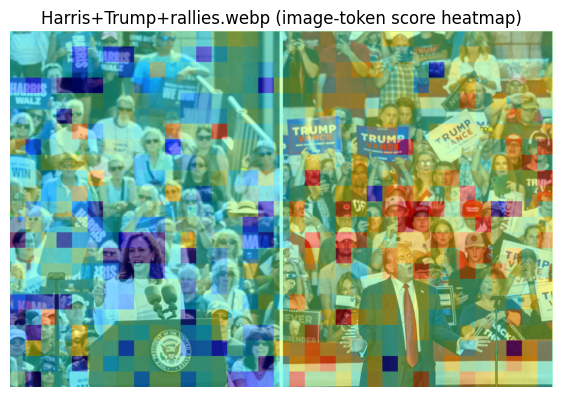

Removing BOS token


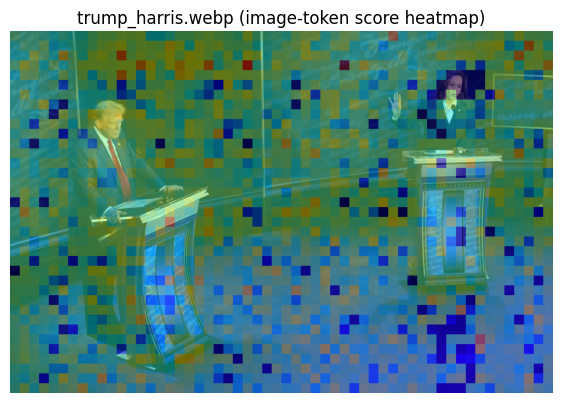

Removing BOS token


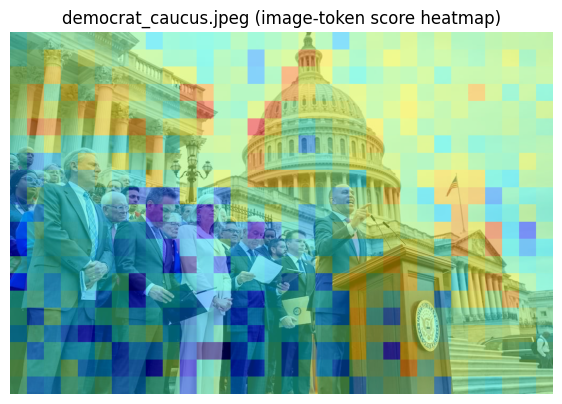

Removing BOS token


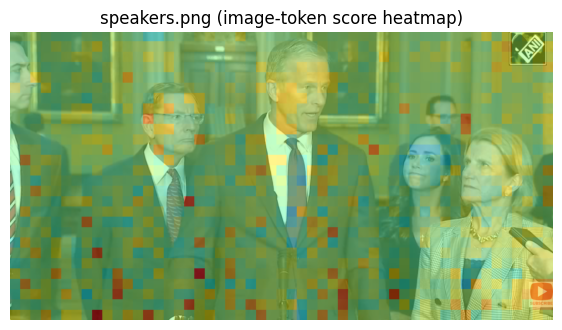

In [17]:
def encode_prompt(processor, image_path):
    """Encode vision model inputs using a chat template."""
    messages = [{
        "role": "user",
        "content": [
            {"type": "text", "text": "write a possible news article that would best accompany this image, from the best possible media outlet. Use your knowledge about American political culture and the media landscape in doing so. If the image seems slanted, write a slanted article. Do not worry about neutrality: write the article in the style of the media outlet most likely to have used this image."},
            {
                "type": "image",
                "image": image_path,
            },
        ],
    }]
    return processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    )

images = os.listdir("./data/rep_dem")
prompts = [encode_prompt(processor, f"./data/rep_dem/{img}") for img in images]

results = generate_and_score_tokens(
    model_path=model_path,
    prompts=prompts,
    model=model,
    tokenizer=processor.tokenizer,
    max_new_tokens=10,
    k=16,
    ridge_prefix="politician",
    visualize=False,
    mode="vision",
    device=device
)

base_dir = "./data/rep_dem"

for i, img_name in enumerate(images):  # visualize a few
    image_path = os.path.join(base_dir, img_name)

    # Depending on how generate_and_score_tokens returns things, scores might be in:
    # results[i]["scores"] and token ids in results[i]["token_ids"].
    token_ids = results[i]["token_ids"]
    scores = results[i]["scores"]

    visualize_scores_for_one_image(
        image_path=image_path,
        token_ids=token_ids,
        scores=scores,
        processor=processor,
        title=f"{img_name} (image-token score heatmap)",
        save_path=None,   # or f"./vis/{img_name}.png"
        alpha=0.45,
        cmap="jet",
    )


## Red/Blue Color Filter Sensitivity Experiment
Overlay `./data/rep_dem` images with red and blue filters, run token scoring, and compare whether image-token sign classification changes.

  0%|          | 0/3 [00:00<?, ?it/s]

Removing BOS token
Removing BOS token
Removing BOS token


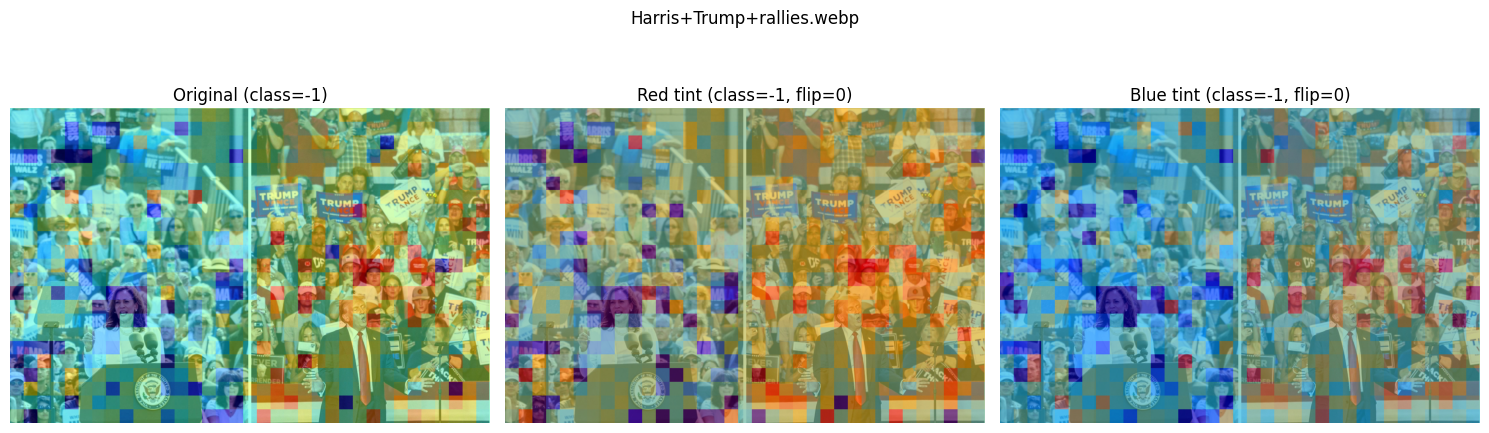

  0%|          | 0/3 [00:00<?, ?it/s]

Removing BOS token
Removing BOS token
Removing BOS token


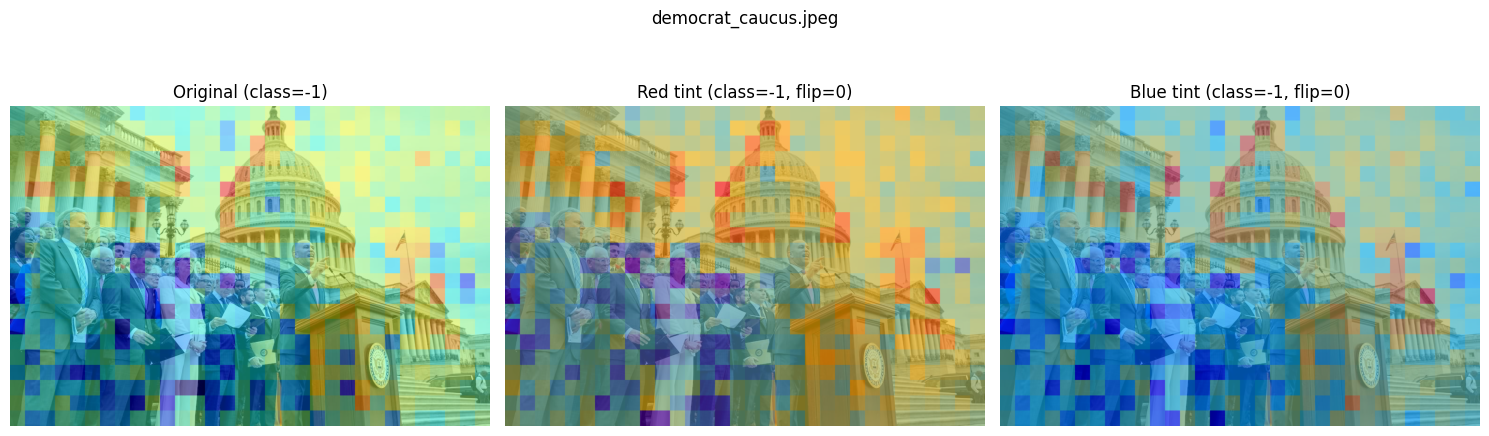

  0%|          | 0/3 [00:00<?, ?it/s]

Removing BOS token
Removing BOS token
Removing BOS token


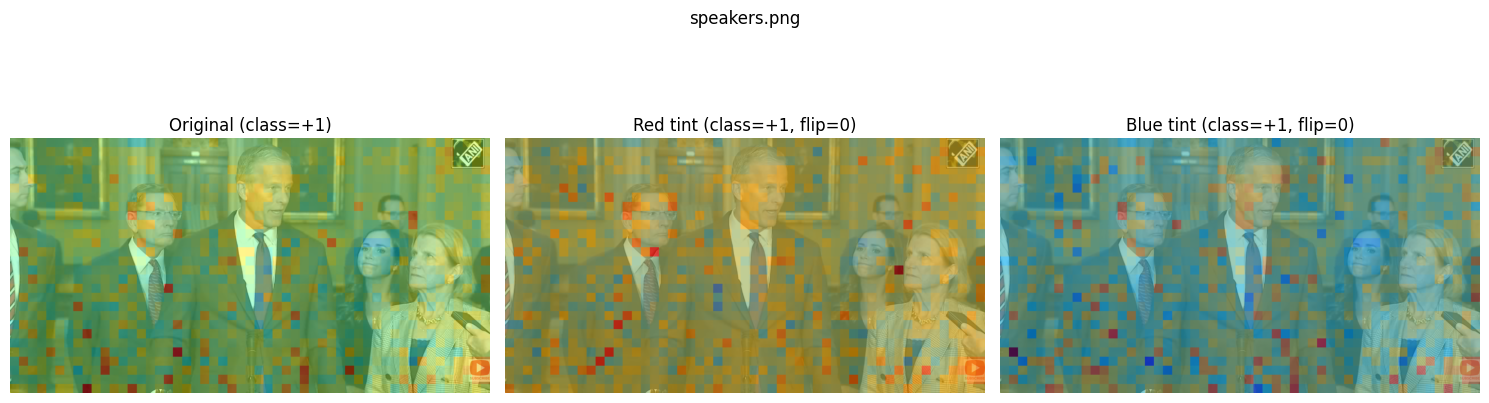

  0%|          | 0/3 [00:00<?, ?it/s]

Removing BOS token
Removing BOS token
Removing BOS token


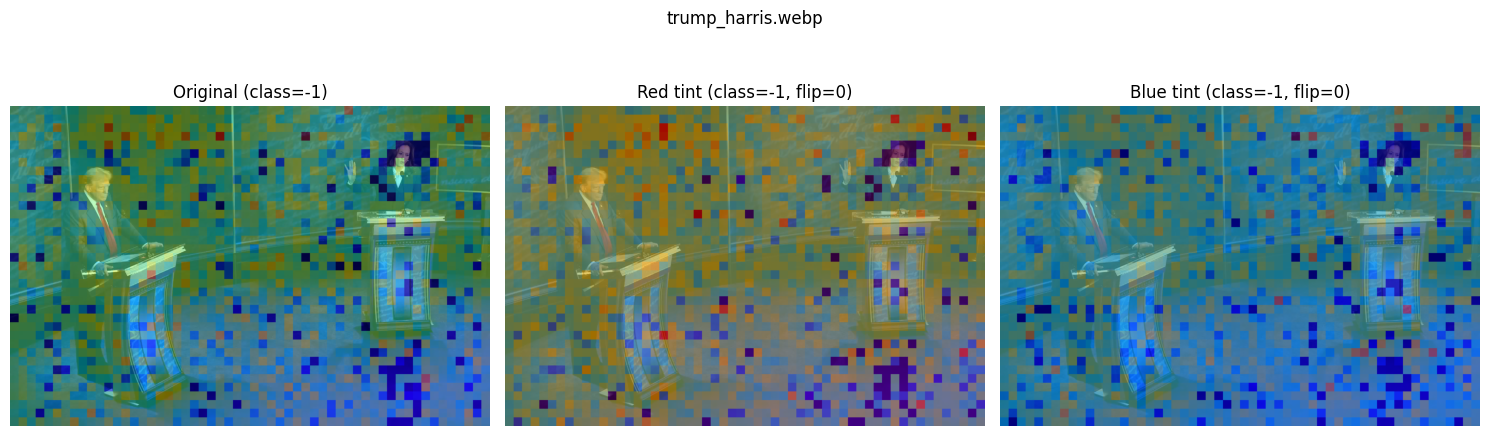

,image,orig_mean,red_mean,blue_mean,orig_class,red_class,blue_class,flip_red,flip_blue
0,Harris+Trump+rallies.webp,-0.056717,-0.046546,-0.043093,-1,-1,-1,0,0
1,democrat_caucus.jpeg,-0.067180,-0.030704,-0.041123,-1,-1,-1,0,0
2,speakers.png,0.061948,0.051707,0.051543,1,1,1,0,0
3,trump_harris.webp,-0.099554,-0.070995,-0.106970,-1,-1,-1,0,0


{'n_images': 4, 'flip_red_rate': 0.0, 'flip_blue_rate': 0.0}


In [18]:
# Experiment: do red/blue color overlays change image-token score classification?
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import pandas as pd

REP_DEM_DIR = "./data/rep_dem"
N_EXPERIMENT_IMAGES = 8
FILTER_ALPHA = 0.35  # amount of tint blended into the original image

def tint_image(img_pil, color_rgb=(255, 0, 0), alpha=0.35):
    """Return an RGB image blended with a solid color overlay."""
    base = np.asarray(img_pil.convert("RGB")).astype(np.float32)
    tint = np.zeros_like(base)
    tint[..., 0] = color_rgb[0]
    tint[..., 1] = color_rgb[1]
    tint[..., 2] = color_rgb[2]
    out = (1.0 - alpha) * base + alpha * tint
    return Image.fromarray(np.clip(out, 0, 255).astype(np.uint8))

def encode_prompt_from_pil(processor, img_pil, prompt_text):
    messages = [{
        "role": "user",
        "content": [
            {"type": "text", "text": prompt_text},
            {"type": "image", "image": img_pil},
        ],
    }]
    return processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )

def score_class_from_image_tokens(token_ids, scores, tokenizer):
    img_scores, _ = extract_image_token_scores(token_ids, scores, tokenizer)
    # simple sign-based class: positive mean -> +1, otherwise -1
    return (1 if float(np.mean(img_scores)) > 0 else -1), img_scores

if "model" not in globals() or "processor" not in globals():
    raise RuntimeError("Run the Qwen3 VL model/processor setup cells first.")

prompt_text = (
    "write a possible news article that would best accompany this image, from the best possible media outlet. "
    "Use your knowledge about American political culture and the media landscape in doing so. "
    "If the image seems slanted, write a slanted article. Do not worry about neutrality: "
    "write the article in the style of the media outlet most likely to have used this image."
)

image_paths = []
for ext in ("*.jpg", "*.jpeg", "*.png", "*.webp"):
    image_paths.extend(glob.glob(os.path.join(REP_DEM_DIR, ext)))
image_paths = sorted(image_paths)[:N_EXPERIMENT_IMAGES]

rows = []
for image_path in image_paths:
    img = Image.open(image_path).convert("RGB")
    img_red = tint_image(img, color_rgb=(255, 0, 0), alpha=FILTER_ALPHA)
    img_blue = tint_image(img, color_rgb=(0, 0, 255), alpha=FILTER_ALPHA)

    prompts = [
        encode_prompt_from_pil(processor, img, prompt_text),
        encode_prompt_from_pil(processor, img_red, prompt_text),
        encode_prompt_from_pil(processor, img_blue, prompt_text),
    ]

    results = generate_and_score_tokens(
        model_path=model_path,
        prompts=prompts,
        model=model,
        tokenizer=processor.tokenizer,
        max_new_tokens=10,
        k=16,
        ridge_prefix="politician",
        visualize=False,
        mode="vision",
        device=device,
    )

    c0, s0 = score_class_from_image_tokens(results[0]["token_ids"], results[0]["scores"], processor.tokenizer)
    cr, sr = score_class_from_image_tokens(results[1]["token_ids"], results[1]["scores"], processor.tokenizer)
    cb, sb = score_class_from_image_tokens(results[2]["token_ids"], results[2]["scores"], processor.tokenizer)

    flip_red = int(cr != c0)
    flip_blue = int(cb != c0)

    rows.append({
        "image": os.path.basename(image_path),
        "orig_mean": float(np.mean(s0)),
        "red_mean": float(np.mean(sr)),
        "blue_mean": float(np.mean(sb)),
        "orig_class": c0,
        "red_class": cr,
        "blue_class": cb,
        "flip_red": flip_red,
        "flip_blue": flip_blue,
    })

    # Visualize original + color overlays with score heatmaps.
    W, H = img.size
    grid_h, grid_w = vision_grid_hw(H, W, processor)

    h0 = s0.reshape(grid_h, grid_w)
    hr = sr.reshape(grid_h, grid_w)
    hb = sb.reshape(grid_h, grid_w)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    overlays = [
        overlay_heatmap_on_image(img, h0, alpha=0.45, cmap="jet", vmin=-1, vmax=1),
        overlay_heatmap_on_image(img_red, hr, alpha=0.45, cmap="jet", vmin=-1, vmax=1),
        overlay_heatmap_on_image(img_blue, hb, alpha=0.45, cmap="jet", vmin=-1, vmax=1),
    ]
    titles = [
        f"Original (class={c0:+d})",
        f"Red tint (class={cr:+d}, flip={flip_red})",
        f"Blue tint (class={cb:+d}, flip={flip_blue})",
    ]
    for ax, over, ttl in zip(axes, overlays, titles):
        ax.imshow(over)
        ax.set_title(ttl)
        ax.axis("off")
    plt.suptitle(os.path.basename(image_path))
    plt.tight_layout()
    plt.show()

df_overlay = pd.DataFrame(rows)
display(df_overlay)

summary = {
    "n_images": int(len(df_overlay)),
    "flip_red_rate": float(df_overlay["flip_red"].mean()) if len(df_overlay) else float("nan"),
    "flip_blue_rate": float(df_overlay["flip_blue"].mean()) if len(df_overlay) else float("nan"),
}
print(summary)

## Mixmatch politicians and non-politician features using nano banana.

- representation
- features -> bias -> behaviors?
- agents -> community behaviors -> polarization?
- extend controllability by understanding


1. gemma 4/qwen omni replication
2. rfm implementation, probing, do newer and better models better capture political bias?
3. think about the bias control stories

1. textual probe, if textual probe is combined with vision, it learned more robust representation of political ideology, compare similarity
2. validate the robustness of the multimodal representation, test multimodal is better (increasingly nuanced political stuff, see if multimodal is better at capturing the nuance)
3. what are the associated geographic, lifestyle, symbolic faetures of political ideology that is captured by the model (ask steered model what do you like to do for weekend)
portraits, lifestyles -> show that what isn't explicitly political can still be captured by the model and can be used for control
4. steering using textual features and visual features identified in step 3

alien humans constructed from steered persona, who are they? outlier persona?